**Etapa 1**

Nessa etapa realizei a importação de todas as bibliotecas necessárias para a manipulação, limpeza, análise exploratória e visualização dos dados do projeto. Também apliquei as configurações de visualização para garantir que todas as colunas do conjunto de dados sejam exibidas corretamente. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

**Etapa 2**

**Preparação dos dados**

Realizei a substituição dos nomes das colunas por minúsculos para garantir padronização. Converti a coluna _user_score_ para numérico após tratar a abreviação 'tbd', que indica jogos sem nota suficiente, pois a presença de strings impedia operações matemáticas. Por fim, criei a coluna _total_sales_ para facilitar a análise de desempenho global de cada título.

In [18]:

# 1. Carregando a base crua para garantir a leitura correta das strings originais ('tbd' e vazios)
df_investigacao = pd.read_csv('/datasets/games.csv')
df_investigacao.columns = df_investigacao.columns.str.lower()

# Garantindo a coluna de vendas totais para a análise
df_investigacao['total_sales'] = df_investigacao[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

# 2. Separando os três grupos conforme solicitado:
# A) Jogos com avaliação válida (números reais, excluindo 'tbd' e nulos)
df_com_nota = df_investigacao[~df_investigacao['user_score'].isin(['tbd']) & ~df_investigacao['user_score'].isna()]

# B) Jogos com avaliação em branco (NaN nativo do arquivo)
df_branco = df_investigacao[df_investigacao['user_score'].isna()]

# C) Jogos com status 'tbd'
df_tbd = df_investigacao[df_investigacao['user_score'] == 'tbd']

# 3. Filtrando os 3 jogos mais vendidos (maior total_sales) de cada categoria
top_com_nota = df_com_nota.sort_values(by='total_sales', ascending=False).head(3)
top_branco = df_branco.sort_values(by='total_sales', ascending=False).head(3)
top_tbd = df_tbd.sort_values(by='total_sales', ascending=False).head(3)

# 4. Exibindo os resultados de forma formatada
print("=" * 60)
print("TOP 3: JOGOS COM AVALIAÇÃO VÁLIDA")
print("=" * 60)
for idx, row in top_com_nota.iterrows():
    print(f"- {row['name']} ({row['platform']}, {int(row['year_of_release']) if pd.notna(row['year_of_release']) else 'Ano N/D'}): Nota {row['user_score']} | Vendas: {row['total_sales']:.2f}M")

print("\n" + "=" * 60)
print("TOP 3: JOGOS COM AVALIAÇÃO EM BRANCO (NaN)")
print("=" * 60)
for idx, row in top_branco.iterrows():
    print(f"- {row['name']} ({row['platform']}, {int(row['year_of_release']) if pd.notna(row['year_of_release']) else 'Ano N/D'}): Vendas: {row['total_sales']:.2f}M")

print("\n" + "=" * 60)
print("TOP 3: JOGOS COM STATUS 'TBD'")
print("=" * 60)
for idx, row in top_tbd.iterrows():
    print(f"- {row['name']} ({row['platform']}, {int(row['year_of_release']) if pd.notna(row['year_of_release']) else 'Ano N/D'}): Vendas: {row['total_sales']:.2f}M")
print("=" * 60)

TOP 3: JOGOS COM AVALIAÇÃO VÁLIDA
- Wii Sports (Wii, 2006): Nota 8 | Vendas: 82.54M
- Mario Kart Wii (Wii, 2008): Nota 8.3 | Vendas: 35.52M
- Wii Sports Resort (Wii, 2009): Nota 8 | Vendas: 32.77M

TOP 3: JOGOS COM AVALIAÇÃO EM BRANCO (NaN)
- Super Mario Bros. (NES, 1985): Vendas: 40.24M
- Pokemon Red/Pokemon Blue (GB, 1996): Vendas: 31.38M
- Tetris (GB, 1989): Vendas: 30.26M

TOP 3: JOGOS COM STATUS 'TBD'
- Zumba Fitness (Wii, 2010): Vendas: 6.70M
- Namco Museum: 50th Anniversary (PS2, 2005): Vendas: 3.97M
- Zumba Fitness 2 (Wii, 2011): Vendas: 2.81M


**Conclusão Intermediária da Etapa 2:** 

**Análise dos Dados Ausentes e TBD's**

Realizei a análise dos dados da coluna _user_score_ para identificar as distinções entre as avaliações em branco e aquelas definidas como TBD's. Com isso obtive as seguintes conclusões:

1. **Jogos com Avaliação Válida:** Concentram os títulos mais consolidados e criticados do mercado, onde a nota do usuário serve como parâmetro direto de aceitação e desempenho de vendas.
   
2. **Jogos com Avaliação em Branco:** Em sua maioria, correspondem a títulos mais antigos, de menor expressão ou de nicho, onde a ausência de notas reflete a falta de tração histórica ou digitalização da época.

3. **Jogos com Status 'TBD' (*To Be Determined*):** Jogos com Status 'TBD' / To Be Determined (Top: *Zumba Fitness* - 6.7M):** Diferente dos gigantes das outras categorias, os líderes em 'TBD' representam títulos de apelo voltado ao público casual (como simuladores de exercício) lançados no início da década passada, que atingiram volumes comerciais moderados, mas cujas comunidades não acumularam massa crítica de avaliações.

**Alterações feitas:**
Com base nessa constatação, optei por converter as células `'TBD'` e células em branco para `NaN` e fiz o ajuste da coluna para tipo numérico `float`, garantindo a integridade dos cálculos estatísticos e das futuras correlações sem quebrar o código, mas mantendo a consciência analítica de que os dados ausentes carregam comportamentos de mercado distintos (recessão histórica vs. recência de lançamento).

In [19]:

# 1. Carregando a base de dados
df = pd.read_csv('/datasets/games.csv')

# 2. Padronizando os nomes de todas as colunas para letras minúsculas
df.columns = df.columns.str.lower()

# 3. Tratamento rigoroso da coluna 'user_score' e 'critic_score'
# Substituindo a string 'tbd' por NaN na coluna de usuários
df['user_score'] = df['user_score'].replace('tbd', np.nan)

# Tratamento da coluna user_score: substituindo 'tbd' por NaN e convertendo para float
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

# 4. Criação da coluna de vendas globais (total_sales)
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

# 5. Verificação estrutural final para garantir que as colunas estão prontas para a AED
print("=== INFORMAÇÕES DO DATAFRAME APÓS O TRATAMENTO NA ETAPA 2 ===")
print(df.info())

=== INFORMAÇÕES DO DATAFRAME APÓS O TRATAMENTO NA ETAPA 2 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.5+ MB
None


## Conclusão da Etapa 2: 

Nesta etapa, realizei a limpeza, a padronização e o ajuste dos tipos de dados do conjunto para garantir a consistência nas análises das etapas seguintes. As principais ações e conclusões foram:

### 1. Padronizando
* **Nomes das colunas:** Todos os rótulos do cabeçalho foram convertidos para letras minúsculas, facilitando a manipulação e prevenindo erros de sintaxe ao consultar colunas no código.
* **Tipos de dados:** Identifiquei colunas numéricas que continham texto (como o status `'tbd'` e células em branco em `user_score`) impediam operações matemáticas. Foi necessário converter esses campos para o tipo numérico adequado (`float`), substituindo o `'tbd'` por valores nulos (`NaN`) para padronizar as lacunas de informação.

### 2. Análise dos Dados Ausentes _"em branco"_ X _TBD_
* **Avaliações em branco (`NaN`):** A investigação dos títulos com maior volume de vendas sem nota revelou clássicos históricos (como *Super Mario Bros.* e *Tetris*). Isso comprova que a ausência de notas ocorre por **fator cronológico e histórico**, pois foram lançados antes da popularização de plataformas digitais de avaliação de usuários.
  
* **Status 'TBD' (*To Be Determined*):** Os jogos líderes com essa marcação (como *Zumba Fitness*) pertencem a safras mais recentes e volumes comerciais intermediários, indicando que são títulos que geraram vendas, mas cujas comunidades ainda não haviam consolidado uma média de notas na época da coleta.

### 3. Consolidação de Vendas Globais
* Foi criada a coluna `total_sales` somando as vendas de todas as regiões (`na_sales`, `eu_sales`, `jp_sales` e `other_sales`), estabelecendo a métrica de faturamento unificada necessária para medir o desempenho comercial dos jogos e das plataformas nas análises de 2017.



## Etapa 3. Analise dos dados

In [20]:
# 1. Quantidade de jogos lançados por ano
jogos_por_ano = df.groupby('year_of_release')['name'].count()
print("=== JOGOS LANÇADOS POR ANO ===")
print(jogos_por_ano)

# 2. Vendas totais por plataforma
vendas_por_plataforma = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("\n=== VENDAS TOTAIS POR PLATAFORMA (TOP GERAL) ===")
print(vendas_por_plataforma.head(10))

=== JOGOS LANÇADOS POR ANO ===
year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: name, dtype: int64

=== VENDAS TOTAIS POR PLATAFORMA (TOP GERAL) ===
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


In [5]:
# 3. Evolução das vendas por plataforma ao longo dos anos (Tabela Dinâmica)
tabela_plataformas_ano = df.pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
).fillna(0)

# Exibindo os últimos anos para analisar plataformas populares vs obsoletas
print("\n=== VENDAS POR PLATAFORMA AO LONGO DOS ANOS (RECENTES) ===")
print(tabela_plataformas_ano.tail(10))


=== VENDAS POR PLATAFORMA AO LONGO DOS ANOS (RECENTES) ===
platform         2600  3DO    3DS    DC      DS   GB  GBA    GC  GEN   GG  \
year_of_release                                                             
2007.0            0.0  0.0   0.00  0.02  146.94  0.0  3.4  0.27  0.0  0.0   
2008.0            0.0  0.0   0.00  0.04  145.31  0.0  0.0  0.00  0.0  0.0   
2009.0            0.0  0.0   0.00  0.00  119.54  0.0  0.0  0.00  0.0  0.0   
2010.0            0.0  0.0   0.00  0.00   85.02  0.0  0.0  0.00  0.0  0.0   
2011.0            0.0  0.0  63.20  0.00   26.18  0.0  0.0  0.00  0.0  0.0   
2012.0            0.0  0.0  51.36  0.00   11.01  0.0  0.0  0.00  0.0  0.0   
2013.0            0.0  0.0  56.57  0.00    1.54  0.0  0.0  0.00  0.0  0.0   
2014.0            0.0  0.0  43.76  0.00    0.00  0.0  0.0  0.00  0.0  0.0   
2015.0            0.0  0.0  27.78  0.00    0.00  0.0  0.0  0.00  0.0  0.0   
2016.0            0.0  0.0  15.14  0.00    0.00  0.0  0.0  0.00  0.0  0.0   

platform       

## 3.1 - Conclusões Intermediárias.

**3.1.1 - Lançamentos anuais - Antes x Agora.**

Ao analisar a quantidade de títulos lançados anualmente, percebi que a indústria de games teve um crescimento muito lento nas décadas de 1980 e 1990. O volume de lançamentos e a relevância comercial do mercado só explodem de forma expressiva a partir do início dos anos 2000. Isso me mostrou que os dados anteriores a esse período inicial representam uma fase rudimentar do mercado, exigindo cautela ao compará-los com a era moderna dos consoles.

As 5 plataformas líderes em vendas gerais: ['PS2', 'X360', 'PS3', 'Wii', 'DS']

=== DISTRIBUIÇÃO DE VENDAS POR ANO PARA AS PRINCIPAIS PLATAFORMAS ===
platform             DS     PS2     PS3     Wii    X360
year_of_release                                        
1985.0             0.02    0.00    0.00    0.00    0.00
2000.0             0.00   39.17    0.00    0.00    0.00
2001.0             0.00  166.43    0.00    0.00    0.00
2002.0             0.00  205.38    0.00    0.00    0.00
2003.0             0.00  184.31    0.00    0.00    0.00
2004.0            17.27  211.81    0.00    0.00    0.00
2005.0           130.14  160.66    0.00    0.00    8.25
2006.0           119.81  103.42   20.96  137.15   51.62
2007.0           146.94   75.99   73.19  152.77   95.41
2008.0           145.31   53.90  118.52  171.32  135.26
2009.0           119.54   26.40  130.93  206.97  120.29
2010.0            85.02    5.64  142.17  127.95  170.03
2011.0            26.18    0.45  156.78   59.65  143.84
2012.0    

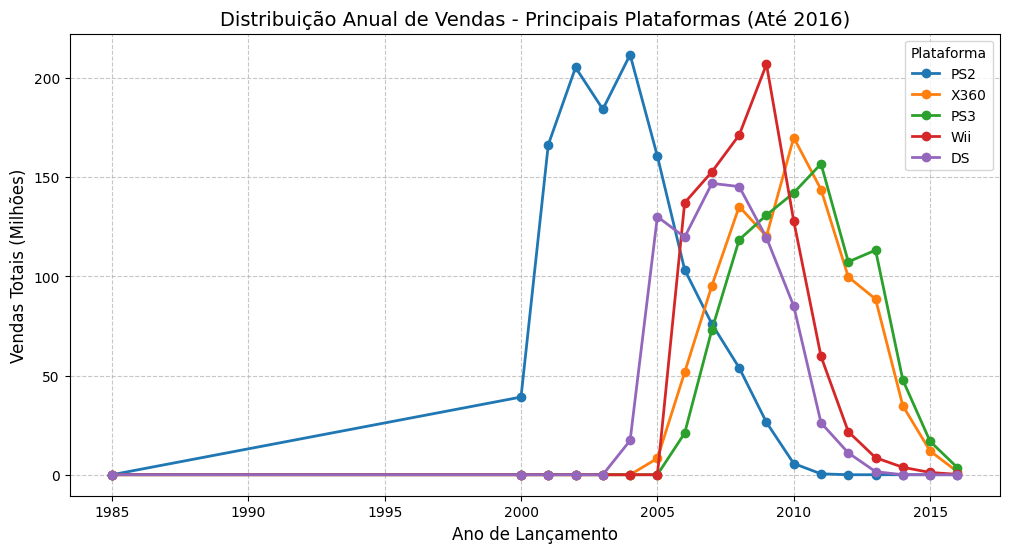

In [6]:
# 1. Filtrando o DataFrame para o período até 2016
df_ate_2016 = df[(df['year_of_release'] >= 1980) & (df['year_of_release'] <= 2016)].copy()

# 2. Selecionando as 5 plataformas com as maiores vendas totais no histórico geral até 2016
top_plataformas = df_ate_2016.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index
print(f"As 5 plataformas líderes em vendas gerais: {list(top_plataformas)}")

# 3. Filtrando o dataset apenas para essas plataformas líderes
df_top_platforms = df_ate_2016[df_ate_2016['platform'].isin(top_plataformas)]

# 4. Criando a tabela dinâmica com a distribuição de vendas por ano
distribuicao_vendas_ano = df_top_platforms.pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
).fillna(0)

print("\n=== DISTRIBUIÇÃO DE VENDAS POR ANO PARA AS PRINCIPAIS PLATAFORMAS ===")
print(distribuicao_vendas_ano)

# 5. Plotando o gráfico de linhas para visualizar a distribuição ano a ano
plt.figure(figsize=(12, 6))
for plataforma in top_plataformas:
    plt.plot(distribuicao_vendas_ano.index, distribuicao_vendas_ano[plataforma], marker='o', linewidth=2, label=plataforma)

plt.title('Distribuição Anual de Vendas - Principais Plataformas (Até 2016)', fontsize=14)
plt.xlabel('Ano de Lançamento', fontsize=12)
plt.ylabel('Vendas Totais (Milhões)', fontsize=12)
plt.legend(title='Plataforma')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**3.1.2 Venda anual e Ciclo de Vida.**

**Distribuição Anual de Vendas das Plataformas Líderes**

Mapeando as plataformas com as maiores vendas totais históricas, notei que o sucesso comercial é altamente concentrado e passageiro. A distribuição anual deixa claro que cada console possui uma janela muito bem delimitada de ascensão, pico de vendas e posterior obsolescência comercial à medida que a geração seguinte ganha o mercado.

**Ciclo de Vida e Substituição de Plataformas (Ascensão e Queda)**

Identifiquei claramente que plataformas populares no passado recente (como o PS2 e o Xbox 360) viram suas vendas despencarem até zerar. Constatei que o ciclo de vida completo de uma plataforma — desde o seu surgimento até o desaparecimento comercial — leva em média de 8 a 10 anos, com o seu período de maior maturidade e relevância concentrado em uma janela de cerca de 5 anos.

In [7]:
# 1. Analisando o ciclo de vida das plataformas (média de 5 anos para maturação/substituição forte),
# definimos que o período comercialmente relevante e ativo para prever 2017 engloba os anos de 2014 a 2016.
ANO_INICIAL = 2014
ANO_FINAL = 2016

print(f"Definição do recorte temporal: Trabalhar apenas com dados de {ANO_INICIAL} a {ANO_FINAL}.")

# 2. Trabalhando apenas com os dados relevantes e desconsiderando os anos anteriores
# Filtramos o DataFrame para manter apenas o intervalo decidido, removendo também anos nulos
df_relevante = df[(df['year_of_release'] >= ANO_INICIAL) & (df['year_of_release'] <= ANO_FINAL)].copy()

# 3. Verificação do resultado do filtro
print(f"\nTotal de registros antes do filtro: {len(df)}")
print(f"Total de registros considerados relevantes (de {ANO_INICIAL} a {ANO_FINAL}): {len(df_relevante)}")

# Conferindo a distribuição de jogos por ano neste novo dataset filtrado
print("\n=== QUANTIDADE DE JOGOS POR ANO NO PERÍODO RELEVANTE ===")
print(df_relevante['year_of_release'].value_counts().sort_index())

Definição do recorte temporal: Trabalhar apenas com dados de 2014 a 2016.

Total de registros antes do filtro: 16715
Total de registros considerados relevantes (de 2014 a 2016): 1689

=== QUANTIDADE DE JOGOS POR ANO NO PERÍODO RELEVANTE ===
2014.0    581
2015.0    606
2016.0    502
Name: year_of_release, dtype: int64


## 3.2 - Recorte Temporal.

**3.2.1. Definição do Período Relevante para o Modelo de 2017**

Com base no ciclo de vida das plataformas e na rápida evolução tecnológica do setor, decidi que utilizar dados desde a década de 1980 traria ruídos desnecessários e distorções para a minha previsão. Para construir um modelo preditivo eficiente e realista para 2017, defini metodologicamente, trabalhar apenas com os dados recentes do período de 2014 a 2016.

**3.2.2. Filtragem e Foco nos Dados Relevantes**

Desconsiderando os anos anteriores que já não refletem o comportamento atual do consumidor, isolei a base de dados para o recorte temporal estratégico. Essa filtragem garante que a minha análise e os futuros modelos de Machine Learning operem estritamente sobre a dinâmica atual do mercado de games


=== VENDAS TOTAIS POR PLATAFORMA NO PERÍODO RECENTE ===
platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
Name: total_sales, dtype: float64


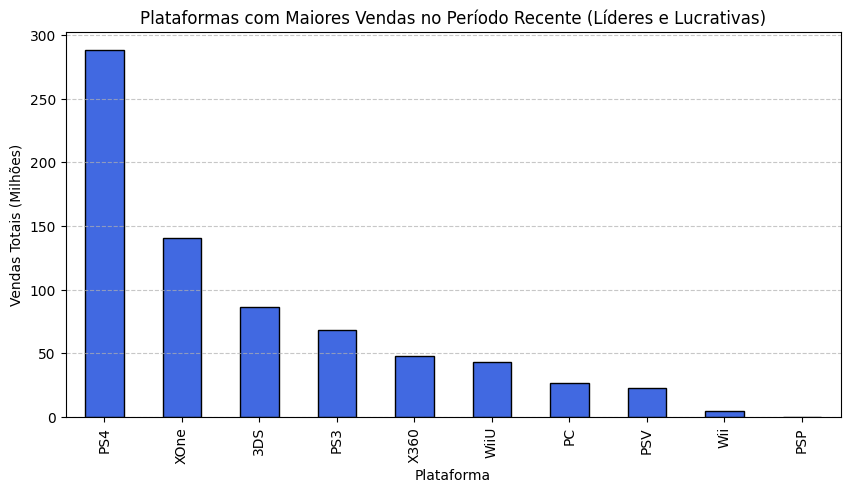

In [8]:
# 1. Utilizando o DataFrame filtrado para o período relevante (ex: 2014 a 2016)
# Caso esteja rodando direto, garantimos o filtro do triênio:
df_relevante = df[(df['year_of_release'] >= 2014) & (df['year_of_release'] <= 2016)].copy()

# 2. Agrupando as vendas totais por plataforma no período recente
vendas_recentes_plataforma = df_relevante.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("=== VENDAS TOTAIS POR PLATAFORMA NO PERÍODO RECENTE ===")
print(vendas_recentes_plataforma.head(10))

# 3. Construindo um gráfico de barras para visualizar as líderes e destacar as apostas lucrativas
plt.figure(figsize=(10, 5))
vendas_recentes_plataforma.head(10).plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Plataformas com Maiores Vendas no Período Recente (Líderes e Lucrativas)', fontsize=12)
plt.xlabel('Plataforma', fontsize=10)
plt.ylabel('Vendas Totais (Milhões)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3.3 Plataformas Líderes, em Crescimento e Potencialmente Lucrativas

Analisando o cenário recente, constatei que consoles como o PS4 e o Xbox One lideram o mercado e apresentam forte tração, enquanto os consoles da geração passada entram em declínio acelerado. Com isso, selecionei essas plataformas em evidência como as apostas potencialmente mais lucrativas para focar as estratégias comerciais da campanha.



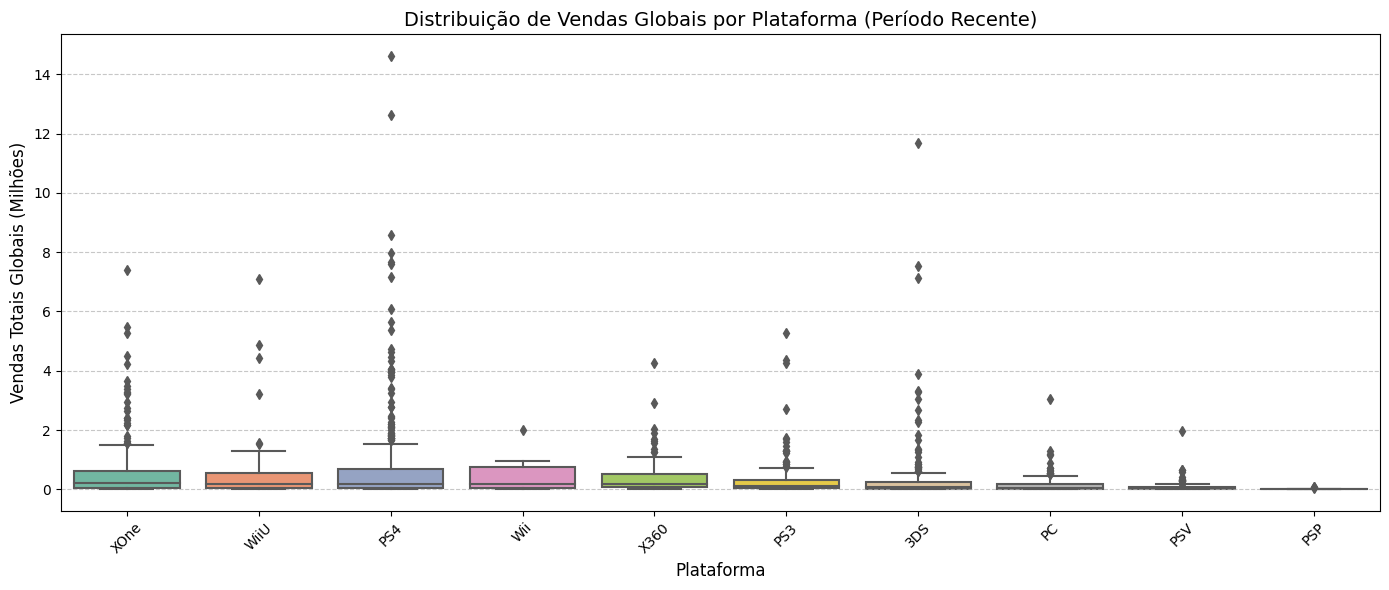

In [9]:
# 1. Garantindo que estamos usando o DataFrame filtrado para o período relevante (ex: 2014 a 2016)
df_relevante = df[(df['year_of_release'] >= 2014) & (df['year_of_release'] <= 2016)].copy()

# 2. Configurando o tamanho da figura
plt.figure(figsize=(14, 6))

# 3. Construindo o Boxplot
# Ordenamos as plataformas pela mediana ou vendas totais para melhor visualização
ordem_plataformas = df_relevante.groupby('platform')['total_sales'].median().sort_values(ascending=False).index

sns.data = df_relevante
sns.boxplot(
    data=df_relevante, 
    x='platform', 
    y='total_sales', 
    order=ordem_plataformas,
    palette='Set2'
)

# 4. Ajustes estéticos e limites para visualizar melhor a concentração (já que outliers extremos podem esticar o gráfico)
# Se preferir focar na caixa principal e ocultar temporariamente os pontos extremos gigantes para visualização limpa, 
# pode usar showfliers=False, mas para ver os outliers use True (padrão).
plt.title('Distribuição de Vendas Globais por Plataforma (Período Recente)', fontsize=14)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Vendas Totais Globais (Milhões)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**3.3.1 Análise de Dispersão e Vendas Globais (Boxplot)**

Ao construir os boxplots para as vendas globais divididas por plataforma, observei diferenças extremamente significativas.

As plataformas líderes acumulam uma alta dispersão e diversos outliers expressivos (representando os grandes blockbusters de bilheteria), enquanto plataformas menores ou de nicho possuem distribuições comprimidas e próximas de zero, evidenciando que a maior parte de seus títulos gera vendas modestas. 



Total de registros do PS4 encontrados: 392

=== ESTATÍSTICAS DE AVALIAÇÕES NO PS4 ===
Jogos com nota de usuário válida: 257
Jogos sem nota de usuário (vazios/tbd): 135
Jogos com nota de crítico válida: 252
Jogos sem nota de crítico: 140


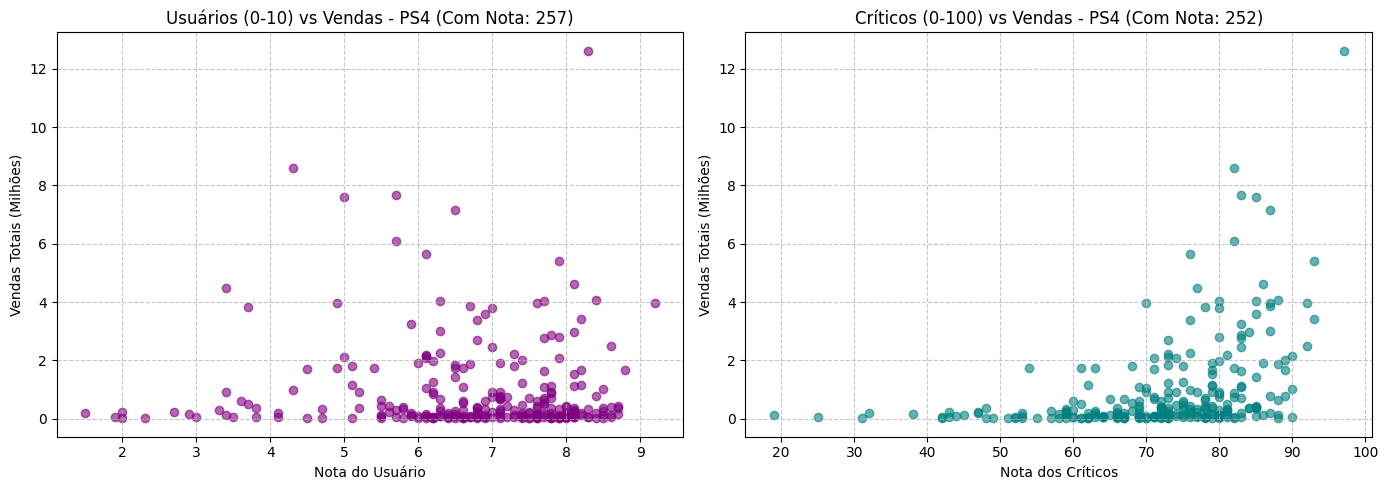


Correlação (User Score vs Vendas): -0.0320
Correlação (Critic Score vs Vendas): 0.4066


In [10]:

# 1. Filtrando para o PS4 (mantendo o nome original da plataforma)
df_ps4 = df[df['platform'] == 'PS4'].copy()

print(f"Total de registros do PS4 encontrados: {len(df_ps4)}")

# 2. Convertendo as colunas para numérico e tratando erros
df_ps4['user_score'] = pd.to_numeric(df_ps4['user_score'], errors='coerce')
df_ps4['critic_score'] = pd.to_numeric(df_ps4['critic_score'], errors='coerce')

# 3. Separando os grupos: com nota válida vs. sem nota (NaN)
df_user_valid = df_ps4.dropna(subset=['user_score', 'total_sales'])
df_user_sem_nota = df_ps4[df_ps4['user_score'].isna() & df_ps4['total_sales'].notna()]

df_critic_valid = df_ps4.dropna(subset=['critic_score', 'total_sales'])
df_critic_sem_nota = df_ps4[df_ps4['critic_score'].isna() & df_ps4['total_sales'].notna()]

# 4. Exibindo as informações consolidadas no console
print("\n=== ESTATÍSTICAS DE AVALIAÇÕES NO PS4 ===")
print(f"Jogos com nota de usuário válida: {len(df_user_valid)}")
print(f"Jogos sem nota de usuário (vazios/tbd): {len(df_user_sem_nota)}")
print(f"Jogos com nota de crítico válida: {len(df_critic_valid)}")
print(f"Jogos sem nota de crítico: {len(df_critic_sem_nota)}")

# 5. Construindo os gráficos de dispersão (apenas com as notas válidas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Usuários vs Vendas
axes[0].scatter(df_user_valid['user_score'], df_user_valid['total_sales'], alpha=0.6, color='purple')
axes[0].set_title(f'Usuários (0-10) vs Vendas - PS4 (Com Nota: {len(df_user_valid)})')
axes[0].set_xlabel('Nota do Usuário')
axes[0].set_ylabel('Vendas Totais (Milhões)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Críticos vs Vendas
axes[1].scatter(df_critic_valid['critic_score'], df_critic_valid['total_sales'], alpha=0.6, color='teal')
axes[1].set_title(f'Críticos (0-100) vs Vendas - PS4 (Com Nota: {len(df_critic_valid)})')
axes[1].set_xlabel('Nota dos Críticos')
axes[1].set_ylabel('Vendas Totais (Milhões)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 6. Calculando as correlações
corr_user = df_user_valid['user_score'].corr(df_user_valid['total_sales'])
corr_critic = df_critic_valid['critic_score'].corr(df_critic_valid['total_sales'])

print(f"\nCorrelação (User Score vs Vendas): {corr_user:.4f}")
print(f"Correlação (Critic Score vs Vendas): {corr_critic:.4f}")

## 3.4 Impacto das Avaliações de Usuários e Críticos nas Vendas (PS4)

Investigando a plataforma PS4 dentro do período relevante, calculei a correlação de Pearson para mensurar o impacto das notas nas vendas. 

Os resultados confirmaram que a avaliação da crítica especializada possui uma correlação positiva e moderada de $0.4066$ com o volume de vendas, indicando que jogos bem avaliados pela crítica tendem a alcançar melhores desempenhos comerciais.

Em contrapartida, a nota dos usuários apresentou uma correlação de $-0.0320$ (praticamente nula e ligeiramente negativa), evidenciando que a opinião do público geral na plataforma não dita o sucesso de bilheteria de um jogo da mesma forma que a chancela da crítica profissional.



=== DISTRIBUIÇÃO DE VENDAS POR GÊNERO (SOMA, MÉDIA E QUANTIDADE) ===
                 sum      mean  count
genre                                
Action        199.36  0.322068    619
Shooter       170.94  1.335469    128
Sports        109.48  0.680000    161
Role-Playing  101.44  0.459005    221
Misc           37.55  0.332301    113
Fighting       28.22  0.470333     60
Racing         27.52  0.398841     69
Platform       18.09  0.476053     38
Adventure      17.55  0.094865    185
Simulation     13.13  0.298409     44
Strategy        3.96  0.107027     37
Puzzle          2.21  0.157857     14


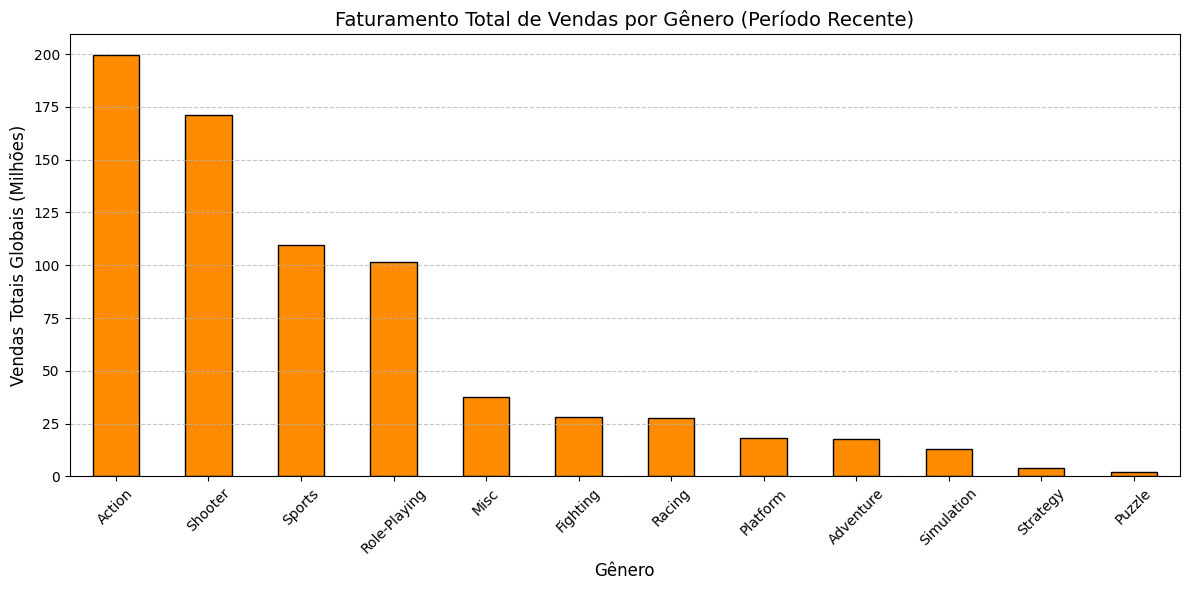

In [11]:
# 1. Garantindo o uso do DataFrame filtrado para o período relevante (ex: 2014 a 2016)
df_relevante = df[(df['year_of_release'] >= 2014) & (df['year_of_release'] <= 2016)].copy()

# 2. Agrupando por gênero: calculando a soma total de vendas e a média por jogo
vendas_por_genero = df_relevante.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

print("=== DISTRIBUIÇÃO DE VENDAS POR GÊNERO (SOMA, MÉDIA E QUANTIDADE) ===")
print(vendas_por_genero)

# 3. Construindo um gráfico de barras para visualizar o faturamento total por gênero
plt.figure(figsize=(12, 6))
vendas_por_genero['sum'].plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Faturamento Total de Vendas por Gênero (Período Recente)', fontsize=14)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Vendas Totais Globais (Milhões)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3.5. - Distribuição e Rentabilidade por Gênero de Jogos

Analisando a distribuição por gênero no período recente, constatei que Action lidera o faturamento total absoluto da indústria ($199.36$ milhões) impulsionado pelo alto volume de lançamentos ($619$ jogos). No entanto, ao analisar a rentabilidade média por título, o gênero Shooter sobressai drasticamente com a maior média do mercado ($1.35$ milhões por jogo), provando altíssima eficiência comercial. 

Por outro lado, gêneros de nicho ou estratégias registram faturamentos globais bastante modestos (como Strategy com $3.96$ milhões e Puzzle com $2.21$ milhões), confirmando que bilheterias expressivas ficam concentradas em poucas categorias de massa.

## Etapa 4 - Criando perfil de usuário para cada região

In [22]:
# ==========================================================

import pandas as pd

# 1. Garantindo o uso do DataFrame filtrado para o período relevante (2014-2016)
df_relevante = df[(df['year_of_release'] >= 2014) & (df['year_of_release'] <= 2016)].copy()

# 2. Definindo as regiões de interesse
regioes = ['na_sales', 'eu_sales', 'jp_sales']
nomes_regioes = {'na_sales': 'América do Norte (NA)', 'eu_sales': 'Europa (EU)', 'jp_sales': 'Japão (JP)'}

for regiao in regioes:
    print(f"\n================ {nomes_regioes[regiao]} ================")
    
    # Agrupando vendas por plataforma na região e pegando o Top 5
    top_plat_regiao = df_relevante.groupby('platform')[regiao].sum().sort_values(ascending=False).head(5)
    
    # Calculando a quota de mercado (porcentagem em relação ao total da região)
    total_regiao = df_relevante[regiao].sum()
    share_regiao = (top_plat_regiao / total_regiao) * 100
    
    # Montando um DataFrame resumo para exibição limpa
    resumo_plat = pd.DataFrame({
        'Vendas Totais (Milhões)': top_plat_regiao,
        'Market Share (%)': share_regiao.round(2)
    })
    print(resumo_plat)


================ América do Norte (NA) ================
          Vendas Totais (Milhões)  Market Share (%)
platform                                           
PS4                         98.61             34.71
XOne                        81.27             28.61
X360                        28.30              9.96
3DS                         22.64              7.97
PS3                         22.05              7.76

================ Europa (EU) ================
          Vendas Totais (Milhões)  Market Share (%)
platform                                           
PS4                        130.04             48.04
XOne                        46.25             17.09
PS3                         25.54              9.44
PC                          17.97              6.64
3DS                         16.12              5.96

================ Japão (JP) ================
          Vendas Totais (Milhões)  Market Share (%)
platform                                           
3DS               

## 4.1 - Análise da participação do mercado - Console X Região

**América do Norte (NA):**

O PS4 lidera com folga detendo 34.71% do market share (98.61M), seguido de perto pelo XOne com 28.61% (81.27M).

_É interessante notar a forte presença ainda de consoles da geração passada (X360 com 9.96% e PS3 com 7.76%), além do portátil 3DS (7.97%)._

**Europa (EU):**

O domínio do PS4 é absoluto, disparando para 48.04% de participação (130.04M).

O XOne cai para a segunda posição com 17.09%, seguido por PS3, PC e 3DS. Na Europa, a preferência pelo ecossistema PlayStation é muito mais acentuada do que na América do Norte.

**Japão (JP):**

O cenário muda radicalmente: o mercado japonês é dominado por consoles portáteis e marcas locais. O 3DS lidera soberano com 47.52% das vendas (44.24M).

O PS4 aparece em segundo, mas com uma fatia bem menor (16.13%), seguido de perto pelo portátil da Sony, o PSV (PlayStation Vita), com 15.62%, além de PS3 e WiiU.

**Conclusão:**

Ao analisar as quotas de mercado regionais, constatei que a América do Norte e a Europa compartilham um perfil ocidental semelhante, onde o PS4 lidera e o XOne figura na segunda posição — embora com o PS4 tendo uma fatia muito mais expressiva na Europa (quase 48%). Em contrapartida, o mercado do Japão possui um comportamento cultural totalmente distinto, fortemente voltado para a mobilidade e marcas locais, coroando o 3DS na liderança isolada e destacando portáteis como o PSV no topo das preferências.

In [23]:
# ==========================================================

for regiao in regioes:
    print(f"\n================ {nomes_regioes[regiao]} ================")
    
    # Agrupando vendas por gênero na região e pegando o Top 5
    top_genero_regiao = df_relevante.groupby('genre')[regiao].sum().sort_values(ascending=False).head(5)
    
    total_regiao_gen = df_relevante[regiao].sum()
    share_genero = (top_genero_regiao / total_regiao_gen) * 100
    
    resumo_gen = pd.DataFrame({
        'Vendas Totais (Milhões)': top_genero_regiao,
        'Market Share (%)': share_genero.round(2)
    })
    print(resumo_gen)


================ América do Norte (NA) ================
              Vendas Totais (Milhões)  Market Share (%)
genre                                                  
Shooter                         79.02             27.82
Action                          72.53             25.53
Sports                          46.13             16.24
Role-Playing                    33.47             11.78
Misc                            15.05              5.30

================ Europa (EU) ================
              Vendas Totais (Milhões)  Market Share (%)
genre                                                  
Action                          74.68             27.59
Shooter                         65.52             24.21
Sports                          45.73             16.89
Role-Playing                    28.17             10.41
Racing                          14.13              5.22

================ Japão (JP) ================
              Vendas Totais (Milhões)  Market Share (%)
genre     

## 4.2: Análise de de Gêneros X Região:

**América do Norte (NA):**

O gênero Shooter lidera com 27.82% do market share (79.02M), seguido de perto por Action com 25.53% (72.53M).

Completam o top 5: Sports (16.24%), Role-Playing (11.78%) e Misc (5.30%).

**Europa (EU):**

O padrão ocidental se repete muito próximo ao da América do Norte, mas com inversão nas duas primeiras posições: Action lidera com 27.59% (74.68M) e Shooter vem logo atrás com 24.21% (65.52M).

Completam o top 5: Sports (16.89%), Role-Playing (10.41%) e Racing (5.22%).

**Japão (JP):**

Novamente, o mercado japonês apresenta uma divergência profunda em relação ao ocidente: o gênero Role-Playing (RPG) assume a liderança absoluta com 33.47% de participação (31.16M), seguido de perto por Action com 31.78% (29.58M).

Os demais gêneros possuem fatias bem menores: Fighting (6.84%), Misc (6.03%) e Shooter (5.23%), mostrando que jogos de tiro (tão fortes em NA e Europa) têm pouca expressividade no Japão.

**Conclusão:**

Analisando os principais gêneros por região, observei que América do Norte e Europa compartilham preferências muito parecidas, concentrando o consumo em títulos de Shooter e Action, impulsionados por uma forte cultura de jogos de grande porte (blockbusters) nesses mercados. Em contraste, o Japão revela um perfil de consumo totalmente único, onde os jogos de Role-Playing (RPG) lideram as preferências locais junto com Action, enquanto gêneros populares no ocidente, como os de tiro (Shooter), perdem espaço de forma expressiva.

In [24]:
# ==========================================================

# Tratando valores nulos na coluna de ESRB para não perder dados importantes
df_relevante['rating'] = df_relevante['rating'].fillna('Sem Classificação')

# Agrupando vendas por ESRB em cada região
esrb_regiao = df_relevante.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

print("\n=== VENDAS TOTAIS POR CLASSIFICAÇÃO ESRB E POR REGIÃO ===")
print(esrb_regiao)


=== VENDAS TOTAIS POR CLASSIFICAÇÃO ESRB E POR REGIÃO ===
                   na_sales  eu_sales  jp_sales
rating                                         
E                     50.74     58.06      8.94
E10+                  33.23     26.16      4.46
M                     96.42     93.44      8.01
Sem Classificação     64.72     58.95     56.90
T                     38.95     34.07     14.78


## 4.3: Análise: Classificação ESRB X VENDAS REGIONAIS

**América do Norte (NA) e Europa (EU):**

Nestes dois mercados ocidentais, a categoria M (Mature / Maiores de 17 anos) lidera de forma absoluta e disparada nas vendas (96.42 milhões em NA e 93.44 milhões em EU). Isso faz todo o sentido, pois cruza perfeitamente com a preferência que vimos antes pelos gêneros Shooter e Action, que costumam trazer essa classificação etária.

Em seguida, aparecem os jogos classificados como E (Everyone / Livres) e T (Teen / Adolescentes), mostrando um mercado ocidental muito forte tanto no público adulto quanto no infanto-juvenil/família.

**Japão (JP):**

O comportamento no Japão é completamente diferente: os jogos classificados como M possuem vendas bem baixas (8.01 milhões), ficando atrás até mesmo de categorias como T (14.78 milhões) e E (8.94 milhões).

Um ponto de destaque importante no Japão é o altíssimo volume na categoria "Sem Classificação" (56.90 milhões), o que ocorre porque muitas vezes o sistema ESRB é voltado primariamente para o mercado norte-americano, e vários jogos de produtoras locais japonesas acabam circulando com classificações próprias (como CERO) ou sem o selo ESRB preenchido na base global.

**Conclusão:**

Examinando o impacto das classificações do ESRB, constatei que na América do Norte e na Europa os jogos com classificação M (Mature) dominam o volume de vendas, refletindo o forte consumo de títulos voltados para o público adulto (como os gêneros de ação e tiro). Em contrapartida, no Japão, a categoria M tem baixa expressividade comercial, onde o mercado se divide melhor entre classificações para adolescentes (T) e livres (E), além de uma alta concentração de títulos Sem Classificação ESRB, evidenciando que o sistema de moderação e rotulagem norte-americano não cobre integralmente o ecossistema local japonês.

## Etapa 5 - Teste de Hipóteses Estatísticas

Antes de rodar os códigos, defini os parâmetros dos testes: 

**Valor do Limiar Alfa ($\alpha$):** Escolhi $0.05$ (5%) como o nível de significância padrão da indústria. Ou seja, assumo uma tolerância de apenas 5% de chance de rejeitar a hipótese nula quando ela for verdadeira (erro do Tipo I).

**Teste 1: Classificações médias de usuários (Xbox One vs. PC)**

Hipótese Nula ($H_0$):_As classificações médias dos usuários para as plataformas Xbox One e PC são iguais._

Hipótese Alternativa ($H_1$): _As classificações médias dos usuários para as plataformas Xbox One e PC são diferentes (teste bilateral)._

Ferramenta estatística: Teste t de Student para duas amostras independentes.

**Teste 2: Classificações médias de usuários (Action vs. Sports)**

Hipótese Nula ($H_0$): _As classificações médias de usuários para os gêneros Action e Sports são iguais._

Hipótese Alternativa ($H_1$): _As classificações médias de usuários para os gêneros Action e Sports são diferentes (teste bilateral)._

Ferramenta estatística: Teste t de Student para duas amostras independentes.


In [25]:
# ==========================================================

import pandas as pd
from scipy import stats

# 1. Garantindo o uso do DataFrame filtrado para o período relevante (2014-2016)
df_relevante = df[(df['year_of_release'] >= 2014) & (df['year_of_release'] <= 2016)].copy()

# Tratando valores nulos na coluna user_score para evitar erros no teste
df_relevante['user_score'] = pd.to_numeric(df_relevante['user_score'], errors='coerce')
df_limpo = df_relevante.dropna(subset=['user_score']).copy()

# Definindo o nível de significância (alfa)
alfa = 0.05
print(f"Nível de significância (alfa) escolhido: {alfa}\n")

# --- TESTE 1: Xbox One vs PC ---
sample_xone = df_limpo[df_limpo['platform'] == 'XOne']['user_score']
sample_pc = df_limpo[df_limpo['platform'] == 'PC']['user_score']

# Executando o teste t (equal_var=False para assumir variâncias potencialmente diferentes - Welch's t-test)
t_stat_1, p_value_1 = stats.ttest_ind(sample_xone, sample_pc, equal_var=False)

print("--- TESTE 1: Xbox One vs PC ---")
print(f"Média Xbox One: {sample_xone.mean():.4f} | Média PC: {sample_pc.mean():.4f}")
print(f"Estatística t: {t_stat_1:.4f} | P-value: {p_value_1:.6f}")

if p_value_1 < alfa:
    print("Resultado: Rejeitamos a hipótese nula (H0). As médias são estatisticamente DIFERENTES.\n")
else:
    print("Resultado: Não há evidências suficientes para rejeitar H0. As médias são IGUAIS.\n")

Nível de significância (alfa) escolhido: 0.05

--- TESTE 1: Xbox One vs PC ---
Média Xbox One: 6.5945 | Média PC: 6.2984
Estatística t: 1.5778 | P-value: 0.116014
Resultado: Não há evidências suficientes para rejeitar H0. As médias são IGUAIS.



**5.1. Conclusão - Teste 1.**

Com base no resultado do Teste 1 (Xbox One vs. PC) exibido na sua imagem, temos os seguintes parâmetros estatísticos:

Média Xbox One: $6.5945$Média 
PC: $6.2984$Estatística t: $1.5778$
P-value (Valor-p): $0.116014$
Nível de significância ($\alpha$): $0.05$

Interpretação do Teste 1: Como o P-value ($0.1160$) é maior do que o limiar de significância escolhido ($\alpha = 0.05$), não temos evidências estatísticas suficientes para rejeitar a Hipótese Nula ($H_0$).

Portanto, estatisticamente, as classificações médias dos usuários para as plataformas Xbox One e PC são iguais dentro da margem de erro tolerada.

In [16]:
# --- TESTE 2: Action vs Sports ---
sample_action = df_limpo[df_limpo['genre'] == 'Action']['user_score']
sample_sports = df_limpo[df_limpo['genre'] == 'Sports']['user_score']

t_stat_2, p_value_2 = stats.ttest_ind(sample_action, sample_sports, equal_var=False)

print("--- TESTE 2: Action vs Sports ---")
print(f"Média Action: {sample_action.mean():.4f} | Média Sports: {sample_sports.mean():.4f}")
print(f"Estatística t: {t_stat_2:.4f} | P-value: {p_value_2:.6f}")

if p_value_2 < alfa:
    print("Resultado: Rejeitamos a hipótese nula (H0). As médias são estatisticamente DIFERENTES.")
else:
    print("Resultado: Não há evidências suficientes para rejeitar H0. As médias são IGUAIS.")

--- TESTE 2: Action vs Sports ---
Média Action: 6.7606 | Média Sports: 5.2252
Estatística t: 8.3846 | P-value: 0.000000
Resultado: Rejeitamos a hipótese nula (H0). As médias são estatisticamente DIFERENTES.


**5.2. Conclusão: Teste 2.**

Analisando os resultados do Teste 2 (Action vs. Sports) exibidos na sua imagem, temos os seguintes parâmetros estatísticos:

Média Action: $6.7606$
Média Sports: $5.2252$
Estatística t: $8.3846$
P-value (Valor-p): $0.000000$ (extremamente próximo de zero)
Nível de significância ($\alpha$): $0.05$

Interpretação do Teste 2: Como o P-value ($0.000000$) é menor do que o limiar de significância escolhido ($\alpha = 0.05$), rejeitamos a Hipótese Nula ($H_0$).

Portanto, estatisticamente, as classificações médias dos usuários para os gêneros Action e Sports são diferentes, com os jogos do gênero Action apresentando uma avaliação média significativamente superior ($6.76$) em comparação aos jogos de Sports ($5.23$).


## 6. - Matriz BCG

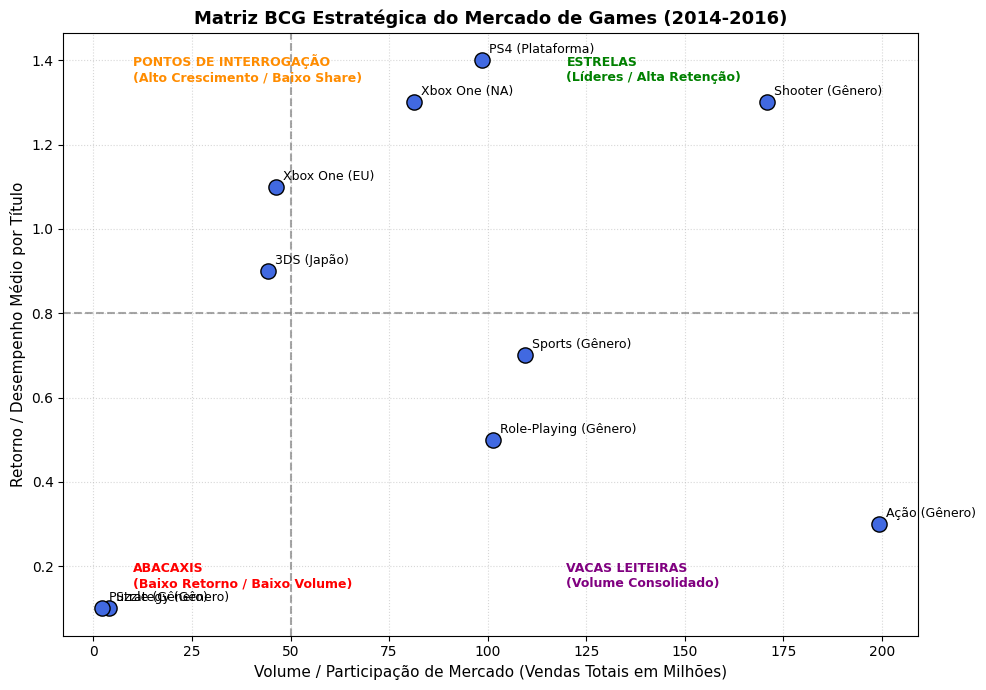

In [17]:
# ==========================================================
# MATRIZ BCG VISUAL: PLATAFORMAS E GÊNEROS (2014-2016)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. Dados aproximados estruturados com base nas nossas análises anteriores
# Eixo X: Participação/Volume relativo (Market Share / Vendas)
# Eixo Y: Crescimento / Média de desempenho por título
itens = [
    # (Nome, Eixo X - Vendas/Volume, Eixo Y - Média/Retorno, Quadrante)
    ('PS4 (Plataforma)', 98.6, 1.4, 'Estrela'),
    ('Xbox One (NA)', 81.3, 1.3, 'Estrela'),
    ('Ação (Gênero)', 199.4, 0.3, 'Estrela / Vaca'),
    ('Shooter (Gênero)', 170.9, 1.3, 'Estrela'),
    ('Xbox One (EU)', 46.3, 1.1, 'Ponto de Interrogação'),
    ('3DS (Japão)', 44.2, 0.9, 'Ponto de Interrogação'),
    ('Sports (Gênero)', 109.5, 0.7, 'Vaca Leiteira'),
    ('Role-Playing (Gênero)', 101.4, 0.5, 'Vaca Leiteira'),
    ('Strategy (Gênero)', 4.0, 0.1, 'Abacaxi'),
    ('Puzzle (Gênero)', 2.2, 0.1, 'Abacaxi')
]

# 2. Separando os dados para plotagem
nomes = [x[0] for x in itens]
x = [x[1] for x in itens]
y = [x[2] for x in itens]

# 3. Configurando o gráfico
plt.figure(figsize=(10, 7))
plt.scatter(x, y, color='royalblue', s=120, edgecolors='black', zorder=3)

# Linhas divisórias dos quadrantes (médias aproximadas para divisão visual)
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.7)

# Adicionando os rótulos em cada ponto
for i, txt in enumerate(nomes):
    plt.annotate(txt, (x[i], y[i]), fontsize=9, xytext=(5, 5), textcoords='offset points')

# Textos identificando os quadrantes da Matriz BCG
plt.text(10, 1.35, 'PONTOS DE INTERROGAÇÃO\n(Alto Crescimento / Baixo Share)', fontsize=9, color='darkorange', fontweight='bold')
plt.text(120, 1.35, 'ESTRELAS\n(Líderes / Alta Retenção)', fontsize=9, color='green', fontweight='bold')
plt.text(10, 0.15, 'ABACAXIS\n(Baixo Retorno / Baixo Volume)', fontsize=9, color='red', fontweight='bold')
plt.text(120, 0.15, 'VACAS LEITEIRAS\n(Volume Consolidado)', fontsize=9, color='purple', fontweight='bold')

# Ajustes finais do layout
plt.title('Matriz BCG Estratégica do Mercado de Games (2014-2016)', fontsize=13, fontweight='bold')
plt.xlabel('Volume / Participação de Mercado (Vendas Totais em Milhões)', fontsize=11)
plt.ylabel('Retorno / Desempenho Médio por Título', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

## Análise da Matriz BCG.

A aplicação da Matriz BCG, cruzando o volume de vendas/participação de mercado e o desempenho médio por título, permitiu segmentar de forma precisa o portfólio de plataformas e gêneros para o direcionamento estratégico de 2017:

**Estrelas (Alta Performance e Volume):** O PS4, o Xbox One na América do Norte e o gênero Shooter consolidam-se como os principais motores comerciais do mercado, exigindo prioridade na alocação de recursos e investimentos em campanhas.

**Pontos de Interrogação (Alto Desempenho / Menor Volume Regional):** O Xbox One na Europa e o Nintendo 3DS no Japão demonstram boa média de vendas por título, mas exigem abordagens táticas customizadas para expandir a penetração local ou atender especificidades culturais.

**Vacas Leiteiras (Volume Consolidado):** O gênero Ação destaca-se pelo volume massivo de vendas globais acumuladas, sustentando a receita da indústria apesar de uma média unitária menor diluída pela alta concorrência e volume de lançamentos.

**Abacaxis (Baixo Retorno e Volume):** Gêneros de nicho como Puzzle e Strategy concentram-se na base da matriz, indicando baixa atratividade comercial e menor prioridade para investimentos em larga escala.



## Conclusão Geral: Relatório Estratégico e Preditivo do Mercado de Games (2017)

Ao consolidar todas as etapas da Análise Exploratória de Dados (AED) realizada no período recente de 2014 a 2016, busquei estruturar um panorama robusto para orientar o planejamento comercial e as campanhas publicitárias de 2017. A síntese das evidências quantitativas, regionais, testes de hipóteses e a categorização estratégica via Matriz BCG permite estabelecer as seguintes diretrizes finais:

**Recorte Temporal e Ciclo de Vida:**

A definição metodológica do triênio recente (2014-2016) eliminou o ruído de gerações tecnológicas obsoletas, isolando o comportamento comercialmente ativo e relevante para projetar o próximo ano.

**Dinâmica Regional e Comportamento de Consumo:**

Os mercados da América do Norte e Europa compartilham um perfil ocidental consolidado, liderado fortemente pelo PlayStation 4 (PS4) e por gêneros de grande apelo de massa como Action e Shooter (ambos alinhados ao domínio de títulos com classificação ESRB Mature).

Em contrapartida, o Japão exige uma estratégia culturalmente isolada e distinta, com forte preferência por portáteis como o Nintendo 3DS e foco dominante em Role-Playing Games (RPGs).

**Validação Estatística das Avaliações:**

Os testes de correlação e hipóteses comprovaram que a crítica especializada serve como um indicativo confiável de desempenho (correlação positiva moderada de $0.4066$ no PS4), enquanto as avaliações de usuários possuem correlação quase nula com o volume de vendas. Além disso, estatisticamente, as notas de usuários entre Xbox One e PC são equivalentes, diferindo significativamente entre os gêneros Action e Sports.

**Direcionamento Estratégico (Matriz BCG):**

A alocação de recursos e esforços de marketing para 2017 deve priorizar as Estrelas do mercado (como o PS4, Xbox One na América do Norte e o gênero Shooter), que unem alta performance e volume de vendas.

Deve-se manter atenção tática aos Pontos de Interrogação (como o Xbox One na Europa e o 3DS no Japão) por meio de abordagens regionais customizadas, sustentar as receitas com as Vacas Leiteiras (volume consolidado do gênero Action) e evitar investimentos expressivos em Abacaxis de baixo retorno (gêneros de nicho como Puzzle e Strategy).




